### Data Explorer
Tasks
- Preprocessing
    - Finding structure scenarios
    - Splitting coordinates into rows (for each player during event) - B
- Plotting
    - puck control
    - position of defensive players
    - passes
    - shots

idea:
- Animate in a rolling 5 (or maybe 3) second window of possession and player moment. Would allow you to see how a play evolves (E)

Todo: Thursday
- Process to automatically find scenarios from game CSV (B)
    - Time from blueline to blueline gt 5 and includes a shot
- algo to seperate when pass and puck control overlaps
- Think about what to present

-----
- From a goal, go x amount of frames backwards
- For now, review shots (and where the shot assist) came from during power play
- Move the players with the slider, but keep the view of the shot static (say last 5-10 actions prior to shot or goal)
- Overlay a Box between all defenders


todo
overlapping defence zone over time (sorta heatmap)

In [36]:
## Import
import urllib.error
import urllib.request
import hockey_rink as hr
import matplotlib.pyplot as plt
import pandas as pd
import os

from PIL.EpsImagePlugin import split
from matplotlib.pyplot import legend

os.listdir()

['(PK) Diamond Shape.png',
 '(PK) Pressure Pushdown (1+Triangle).png',
 '(PK) Protect Inside Box_.png',
 'data_explorer.ipynb',
 'Data_SCFinal.xlsx',
 'PP(5v4)Goals NLA 25-26 (TEST).xlsx',
 'Results &  Questions.docx',
 'Way of Scoring (Data Science).docx']

## Import Data

In [95]:
data_in = pd.read_excel("Data_SCFinal.xlsx", sheet_name="control_example")
data_in

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection3,StartPlayerDirection4,StartPlayerDirection5,StartPlayerDirection6,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12
0,1,1032,1767181288920,BluelineCrossing,HomePowerplay,5v4,True,True,AwayTeamZone,"7.2,11.4",...,"0.954,0.301","0.91,0.415","0.895,0.447","0.741,0.672","0.703,0.711","0.701,0.713","0.618,0.786","0.957,0.291","0.49,0.872",NaN
1,1,1033,1767181290620,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"19,13",...,"0.998,-0.06","0.734,0.679","0.613,-0.79","1,0.014","0.999,-0.045","0.965,-0.26","0.987,0.159","0.763,-0.646","0.762,-0.648",NaN
2,1,1033,1767181290640,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"18.9,13",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1034,1767181291340,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"10.2,14.6",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1037,1767181294600,Dump,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,"0.336,0.942","0.826,0.563","0.021,1","0.381,0.924","0.177,0.984","0.73,-0.684","-0.22,0.976","-0.576,0.818","-0.322,0.947",NaN
5,1,1037,1767181294620,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,1039,1767181296360,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.9,7.5",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,1040,1767181297520,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.3,10.8",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,1041,1767181298560,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"26.7,13.3",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,1045,1767181302300,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"7.9,11.9",...,"-0.814,-0.58","-0.985,-0.173","-0.996,0.085","-0.998,-0.071","-0.999,0.054","-0.972,-0.236","-0.937,-0.348","-0.976,0.217","-0.951,-0.309",NaN


In [97]:
## create dedicated x,y fields for event start, end
data_in[['EventStartX', 'EventStartY']] = (data_in['EventStartCoordinate'].str.split(',', expand=True).astype(float))
data_in[['EventEndX', 'EventEndY']] = (data_in['EventEndCoordinate'].str.split(',', expand=True).astype(float))
data_in = data_in[1:] #remove blue line crossing
data_in

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,EventStartX,EventStartY,EventEndX,EventEndY
2,1,1033,1767181290640,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"18.9,13",...,NaN,NaN,NaN,NaN,NaN,NaN,18.9,13.0,10.2,14.6
3,1,1034,1767181291340,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"10.2,14.6",...,NaN,NaN,NaN,NaN,NaN,NaN,10.2,14.6,8.7,14.5
4,1,1037,1767181294600,Dump,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,"0.177,0.984","0.73,-0.684","-0.22,0.976","-0.576,0.818","-0.322,0.947",NaN,8.7,14.5,29.9,7.6
5,1,1037,1767181294620,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"8.7,14.5",...,NaN,NaN,NaN,NaN,NaN,NaN,8.7,14.5,29.9,7.5
6,1,1039,1767181296360,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.9,7.5",...,NaN,NaN,NaN,NaN,NaN,NaN,29.9,7.5,29.3,10.8
7,1,1040,1767181297520,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"29.3,10.8",...,NaN,NaN,NaN,NaN,NaN,NaN,29.3,10.8,26.7,13.3
8,1,1041,1767181298560,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"26.7,13.3",...,NaN,NaN,NaN,NaN,NaN,NaN,26.7,13.3,7.8,11.8
9,1,1045,1767181302300,Pass,HomePowerplay,5v4,True,True,AwayTeamZone,"7.9,11.9",...,"-0.999,0.054","-0.972,-0.236","-0.937,-0.348","-0.976,0.217","-0.951,-0.309",NaN,7.9,11.9,-0.2,-0.5
10,1,1045,1767181302320,PuckControl,HomePowerplay,5v4,True,True,AwayTeamZone,"7.8,11.8",...,NaN,NaN,NaN,NaN,NaN,NaN,7.8,11.8,-0.2,-0.5


In [71]:
pass_row = data_in.loc[4]
x = float(pass_row['EventStartCoordinate'].split(",")[0])
y = float(pass_row['EventStartCoordinate'].split(",")[1])


In [99]:
## arrows for passes function into list
start_coords = pass_row['EventStartCoordinate'].split(",")
start_coords = [float(i) for i in start_coords]
print(start_coords)

end_coords = pass_row['EventEndCoordinate'].split(",")
end_coords = [float(i) for i in end_coords]
print(end_coords)

[8.7, 14.5]
[29.9, 7.6]


## Hockey-Rink

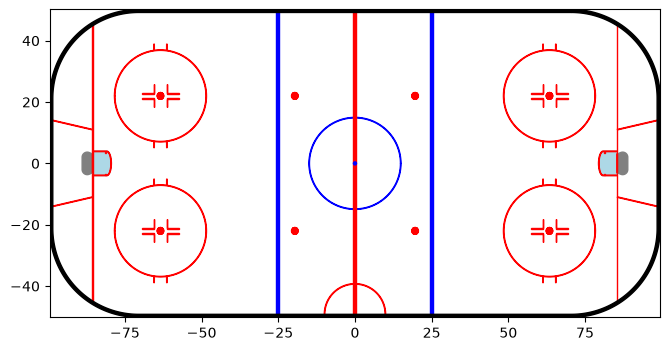

In [111]:
## produce rink drawing
rink = hr.IIHFRink()
rink.draw( , despine = False) #default size 10x4, large is 20x8
plt.show()

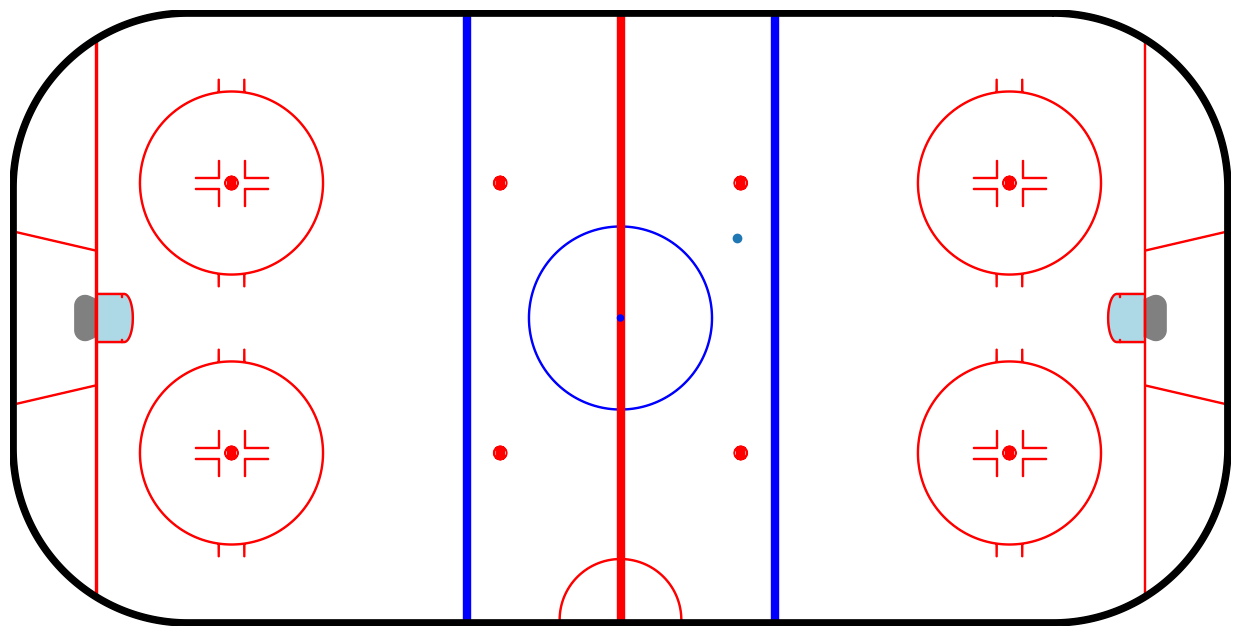

In [56]:
#produce scatter on rink
rink.scatter(x = x,
             y = y,
             draw_kw={"figsize": (20, 8)}
             )
plt.show()

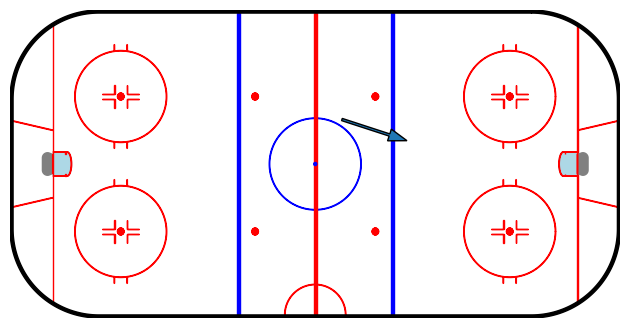

In [76]:
rink.arrow(
    x = start_coords[0],
    y = start_coords[1],

    x2 = end_coords[0],
    y2 = end_coords[1],

    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (10, 4)},
)
plt.show()

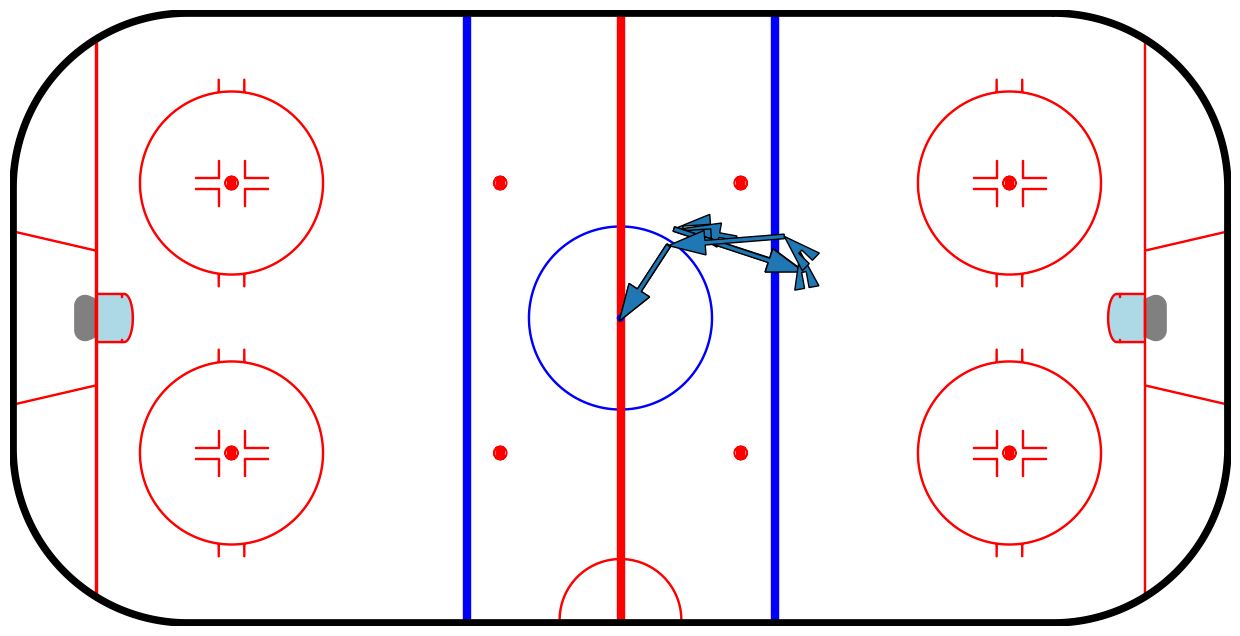

In [101]:
rink.arrow(
    data = data_in,
    x = "EventStartX",
    y = "EventStartY",

    x2 = "EventEndX",
    y2 = "EventEndY",

    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
plt.show()

## Use a set up Structure example
3P0:24 to 3P0:58

In [160]:
structure_df = pd.read_excel("Data_SCFinal.xlsx", sheet_name="structure")
structure_df[['EventStartX', 'EventStartY']] = (structure_df['EventStartCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX', 'EventEndY']] = (structure_df['EventEndCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX']] = structure_df[['EventEndX']]*3.28084
structure_df[['EventEndY']] = structure_df[['EventEndY']]*3.28084
structure_df[['EventStartX']] = structure_df[['EventStartX']]*3.28084
structure_df[['EventStartY']] = structure_df[['EventStartY']]*3.28084
structure_df

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,StartPlayerDirection7,StartPlayerDirection8,StartPlayerDirection9,StartPlayerDirection10,StartPlayerDirection11,StartPlayerDirection12,EventStartX,EventStartY,EventEndX,EventEndY
0,3,15,1767185723200,Pass,AwayPowerplay,4v5,True,True,NeutralZone,"3.2,-3.8",...,"0.122,-0.993","0.463,-0.886","-0.247,-0.969","-0.127,-0.992","-0.17,-0.985",NaN,10.498688,-12.467192,4.921260,34.120736
1,3,15,1767185723220,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"3.1,-3.9",...,NaN,NaN,NaN,NaN,NaN,NaN,10.170604,-12.795276,4.921260,34.120736
2,3,16,1767185724480,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"1.5,10.4",...,NaN,NaN,NaN,NaN,NaN,NaN,4.921260,34.120736,-62.664044,-48.884516
3,3,24,1767185732580,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-19.2,-14.9",...,"-0.748,0.664","-0.331,0.944","-0.907,-0.421","-0.675,0.738","0.067,-0.998",NaN,-62.992128,-48.884516,-29.199476,-45.603676
4,3,24,1767185732600,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-19.1,-14.9",...,NaN,NaN,NaN,NaN,NaN,NaN,-62.664044,-48.884516,-29.199476,-45.603676
5,3,25,1767185733660,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8.9,-13.9",...,NaN,NaN,NaN,NaN,NaN,NaN,-29.199476,-45.603676,-26.574804,-48.556432
6,3,26,1767185734480,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8,-14.8",...,"0.526,0.85","0.257,-0.966","0.513,0.858","0.79,-0.613","-0.205,0.979",NaN,-26.246720,-48.556432,-48.884516,-48.556432
7,3,26,1767185734500,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8.1,-14.8",...,NaN,NaN,NaN,NaN,NaN,NaN,-26.574804,-48.556432,-48.884516,-48.556432
8,3,27,1767185735200,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-14.9,-14.8",...,NaN,NaN,NaN,NaN,NaN,NaN,-48.884516,-48.556432,-45.275592,-44.619424
9,3,28,1767185736200,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-13.8,-13.6",...,"-0.266,0.964","-0.838,0.546","-0.458,-0.889","-0.195,0.981","-0.865,0.501",NaN,-45.275592,-44.619424,-85.629924,-36.745408


In [ ]:
## code for puckcontrol
rink.wavy_arrow(
    data=structure_df[structure_df["EventType"] == "PuckControl"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",
    # facecolor="purple", edgecolor="black",
    head_width=4, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)

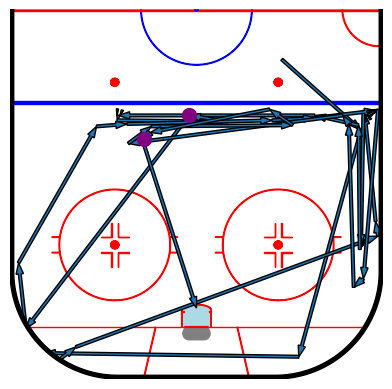

In [159]:
rink.draw(display_range="defence", rotation=90)

rink.arrow(
    data=structure_df[structure_df["EventType"] == "PuckControl"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",
    # facecolor="purple", edgecolor="black",
    head_width=2, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
rink.scatter(
    data=structure_df[structure_df["EventType"] == "Shot"],
    x="EventStartX",
    y="EventStartY",
    color = "purple",
    s=100
)
plt.show()

Not sure why the Pass (arrow) and Puckcontrol (Squiggle) overlap so much

RuntimeError: Invalid vertices array.

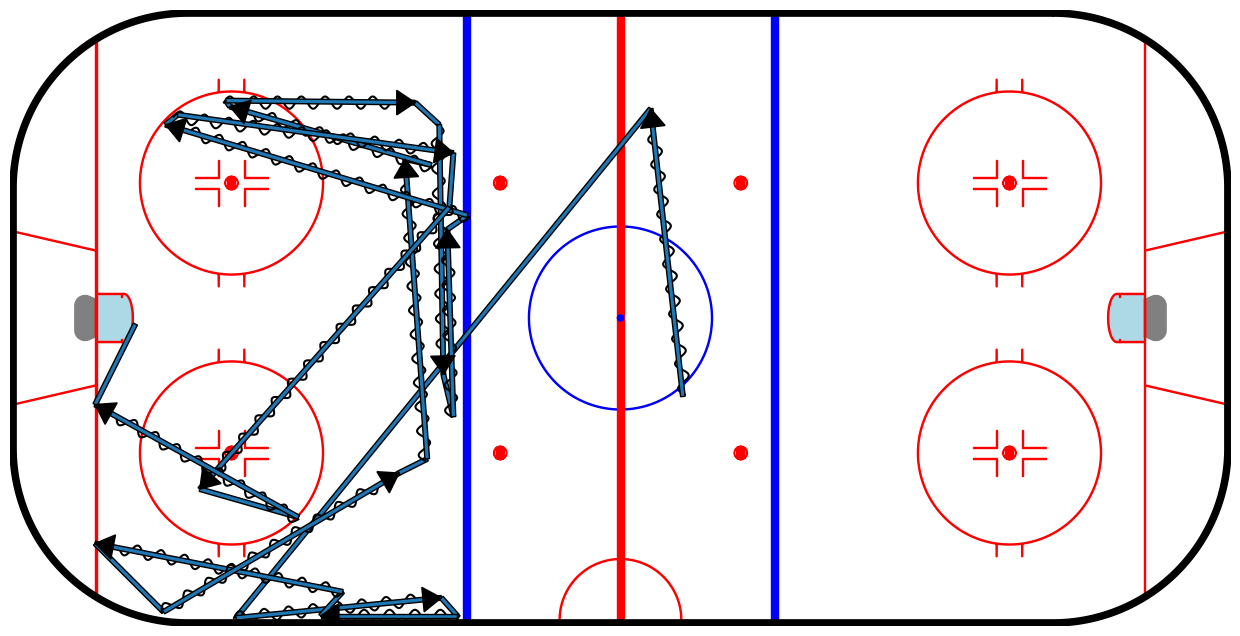

In [149]:
#wanted to see if I could plot these in a loop

for i, row in structure_df.iterrows():
    if row["EventType"] == "Pass":
        rink.wavy_arrow(
            data=row,
            x="EventStartX",
            y="EventStartY",

            x2="EventEndX",
            y2="EventEndY",

            # facecolor="purple", edgecolor="black",
            head_width=4, length_includes_head=True,
            draw_kw={"figsize": (20, 8)},
        )
    else:
        rink.arrow(
            data=row,
            x="EventStartX",
            y="EventStartY",

            x2="EventEndX",
            y2="EventEndY",
             # facecolor="purple", edgecolor="black",
            head_width=0, length_includes_head=True,
            draw_kw={"figsize": (20, 8)},
            )
    plt.show()


## Plotting with Defensive Players & Puck Control Events
Data: Period 3, from time 77 to 114
- Blue Line crossing & faceoff data remove

In [200]:
structure_df = pd.read_excel("Data_SCFinal.xlsx", sheet_name="structure")
#structure_df= structure_df[-10:]

#Split Start, End coords of event
structure_df[['EventStartX', 'EventStartY']] = (structure_df['EventStartCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX', 'EventEndY']] = (structure_df['EventEndCoordinate'].str.split(',', expand=True).astype(float))
## convert coords into feet
structure_df[['EventEndX']] = structure_df[['EventEndX']]*3.28084
structure_df[['EventEndY']] = structure_df[['EventEndY']]*3.28084
structure_df[['EventStartX']] = structure_df[['EventStartX']]*3.28084
structure_df[['EventStartY']] = structure_df[['EventStartY']]*3.28084

# split defensive player coords (home team is defence in this scenario - players 7 to 11)
players = [7, 8, 9, 10, 11]
for i in players:
    structure_df[[f'Player{i}X', f'Player{i}Y']] = (structure_df[f'StartPlayerCoordinates{i}'].str.split(',', expand=True).astype(float))
# convert player coords into feet
for i in players:
    structure_df[[f'Player{i}X']] = structure_df[[f'Player{i}X']]*3.28084
    structure_df[[f'Player{i}Y']] = structure_df[[f'Player{i}Y']]*3.28084

structure_df

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,Player7X,Player7Y,Player8X,Player8Y,Player9X,Player9Y,Player10X,Player10Y,Player11X,Player11Y
0,3,15,1767185723200,Pass,AwayPowerplay,4v5,True,True,NeutralZone,"3.2,-3.8",...,-27.887140,10.498688,-86.286092,-1.312336,-1.640420,0.000000,-11.154856,30.839896,-23.950132,-16.404200
1,3,15,1767185723220,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"3.1,-3.9",...,-27.887140,10.498688,-86.286092,-1.312336,-1.640420,-0.328084,-11.154856,30.839896,-23.950132,-16.732284
2,3,16,1767185724480,PuckControl,AwayPowerplay,4v5,True,True,NeutralZone,"1.5,10.4",...,-30.839896,4.593176,-83.333336,-0.656168,-12.467192,-22.965880,-7.874016,32.808400,-31.824148,-23.950132
3,3,24,1767185732580,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-19.2,-14.9",...,-69.225724,-3.937008,-84.645672,-1.312336,-57.414700,0.000000,-54.461944,-25.262468,-70.538060,-36.417324
4,3,24,1767185732600,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-19.1,-14.9",...,-69.553808,-3.937008,-84.645672,-1.312336,-57.742784,-0.328084,-54.461944,-25.262468,-70.209976,-36.745408
5,3,25,1767185733660,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8.9,-13.9",...,-70.538060,-0.984252,-84.317588,-0.984252,-59.383204,0.656168,-50.524936,-21.325460,-65.288716,-35.761156
6,3,26,1767185734480,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8,-14.8",...,-68.897640,-0.656168,-83.661420,-1.640420,-57.414700,2.952756,-45.603676,-22.309712,-66.272968,-26.902888
7,3,26,1767185734500,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-8.1,-14.8",...,-68.897640,-0.328084,-83.661420,-1.640420,-57.414700,2.952756,-45.275592,-22.309712,-66.272968,-26.574804
8,3,27,1767185735200,PuckControl,AwayPowerplay,4v5,True,True,HomeTeamZone,"-14.9,-14.8",...,-68.241472,1.968504,-83.661420,-1.640420,-55.774280,6.561680,-42.979004,-24.278216,-67.257220,-20.013124
9,3,28,1767185736200,Pass,AwayPowerplay,4v5,True,True,HomeTeamZone,"-13.8,-13.6",...,-69.881892,2.624672,-84.317588,-0.984252,-56.102364,5.577428,-41.994752,-21.981628,-70.538060,-14.107612


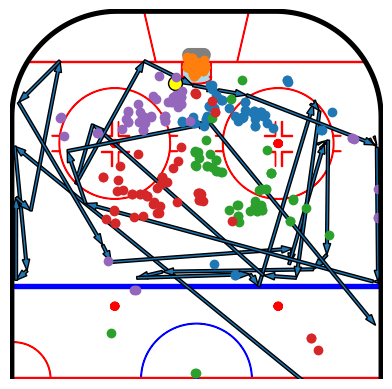

In [201]:
rink.draw(display_range="defence", rotation=270)

rink.arrow(
    data=structure_df[structure_df["EventType"] == "PuckControl"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",
    # facecolor="purple", edgecolor="black",
    head_width=2, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
rink.scatter(
    data=structure_df[structure_df["EventType"] == "Shot"],
    x="EventStartX",
    y="EventStartY",
    color = "yellow",
    s=100,
    edgecolor="black"
)
# plot defensive players
for i in players:
    rink.scatter(
    data=structure_df,
    x = f'Player{i}X',
    y =  f'Player{i}Y'
    )
plt.show()

##  Goal Example (Even Strength)

In [189]:
structure_df = pd.read_excel("Data_SCFinal.xlsx", sheet_name="goal")

#Split Start, End coords of event
structure_df[['EventStartX', 'EventStartY']] = (structure_df['EventStartCoordinate'].str.split(',', expand=True).astype(float))
structure_df[['EventEndX', 'EventEndY']] = (structure_df['EventEndCoordinate'].str.split(',', expand=True).astype(float))
## convert coords into feet
structure_df[['EventEndX']] = structure_df[['EventEndX']]*3.28084
structure_df[['EventEndY']] = structure_df[['EventEndY']]*3.28084
structure_df[['EventStartX']] = structure_df[['EventStartX']]*3.28084
structure_df[['EventStartY']] = structure_df[['EventStartY']]*3.28084

# split defensive player coords (home team is defence in this scenario - players 7 to 11)
players = [7, 8, 9, 10, 11, 12]
for i in players:
    structure_df[[f'Player{i}X', f'Player{i}Y']] = (structure_df[f'StartPlayerCoordinates{i}'].str.split(',', expand=True).astype(float))
# convert player coords into feet
for i in players:
    structure_df[[f'Player{i}X']] = structure_df[[f'Player{i}X']]*3.28084
    structure_df[[f'Player{i}Y']] = structure_df[[f'Player{i}Y']]*3.28084

structure_df

,Period,MatchClock,Timestamp,EventType,TeamStrengthType,TeamStrength,HomeGoalieOnIce,AwayGoalieOnIce,EventPosition,EventStartCoordinate,...,Player8X,Player8Y,Player9X,Player9Y,Player10X,Player10Y,Player11X,Player11Y,Player12X,Player12Y
0,3,912,1767187177640,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-25.3,-0.6",...,-86.614176,-3.608924,-65.944884,7.874016,-73.818900,-30.183728,-44.947508,-19.685040,-79.396328,0.328084
1,3,912,1767187177740,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-25.3,-0.6",...,-86.614176,-3.608924,-66.601052,7.874016,-74.803152,-30.183728,-45.275592,-19.685040,-79.396328,-0.656168
2,3,914,1767187179340,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-29.2,-0.5",...,-86.614176,-2.952756,-76.115488,1.640420,-79.396328,-15.748032,-51.837272,-22.309712,-82.021000,-4.265092
3,3,915,1767187180640,Pass,FullStrength,5v5,True,True,HomeTeamZone,"-28.3,5.5",...,-87.270344,0.000000,-76.771656,7.545932,-76.771656,-0.656168,-56.430448,-15.419948,-85.629924,11.811024
4,3,915,1767187180660,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-28.2,5.6",...,-87.270344,0.000000,-76.771656,7.545932,-76.771656,-0.656168,-56.430448,-15.091864,-85.629924,12.139108
5,3,916,1767187181440,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-16.6,10",...,-85.301840,0.984252,-71.194228,14.435696,-74.803152,5.577428,-56.758532,-9.186352,-82.021000,23.950132
6,3,917,1767187182920,Pass,FullStrength,5v5,True,True,HomeTeamZone,"-17.9,13.7",...,-83.989504,1.640420,-63.648296,31.824148,-71.850396,10.498688,-49.212600,-6.233596,-69.553808,35.104988
7,3,917,1767187182940,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-17.8,13.8",...,-83.989504,1.640420,-63.320212,32.152232,-71.850396,10.498688,-48.884516,-6.233596,-69.553808,35.104988
8,3,918,1767187183620,PuckControl,FullStrength,5v5,True,True,HomeTeamZone,"-13.5,12.2",...,-83.989504,1.312336,-53.805776,34.120736,-69.881892,13.123360,-43.635172,-6.889764,-64.304464,34.120736
9,3,919,1767187184720,Shot,FullStrength,5v5,True,True,HomeTeamZone,"-9.8,4.4",...,-82.349084,0.656168,-41.010500,18.044620,-63.648296,14.107612,-42.322836,-7.217848,-62.007876,27.887140


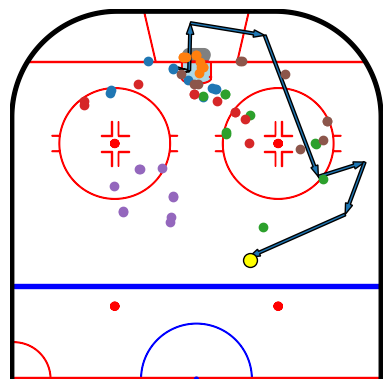

In [190]:
rink.draw(display_range="defence", rotation=270)

rink.arrow(
    data=structure_df[structure_df["EventType"] == "PuckControl"],
    x="EventStartX",
    y="EventStartY",

    x2="EventEndX",
    y2="EventEndY",
    # facecolor="purple", edgecolor="black",
    head_width=2, length_includes_head=True,
    draw_kw={"figsize": (20, 8)},
)
rink.scatter(
    data=structure_df[structure_df["EventType"] == "Shot"],
    x="EventStartX",
    y="EventStartY",
    color = "yellow",
    s=100,
    edgecolor="black"
)
# plot defensive players
for i in players:
    rink.scatter(
    data=structure_df,
    x = f'Player{i}X',
    y =  f'Player{i}Y'
    )

plt.show()

In [206]:
for i in range(1,15):
    excel = pd.read_excel("Fribourg-Gottéron_HC Dynamo Pardubice_Wisehockey_Match_Events_26_12_2024.xlsx", sheet_name=f"shot{i}", )
    ## export
    excel.to_csv(f"{i}.csv", index=False)
    print(f"{i} done")

1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done


ValueError: Worksheet named 'shot12' not found

Interesting to view
Period 3 - clock 42 to 49